In [36]:
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy
import pandas
from functools import lru_cache
from deap import algorithms
from deap import base, creator, tools
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

# PREPARATION

In [37]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [38]:
# Constants
CSV_TRAIN_PATH: str = "diabetes/diabetes_preprocessed_train_data.csv"
#CSV_TEST_PATH: str = "diabetes/diabetes_preprocessed_test_data.csv"
CSV_TEST_PATH: str = "diabetes/diabetes_preprocessed_test_noisy_data.csv"
TARGET_COLUMN: str = "Outcome"

#CSV_TRAIN_PATH: str = "readmit/readmit_130_hospitals_preprocessed_train_data.csv"
#CSV_TEST_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_data.csv"
#CSV_TEST_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_noisy_data.csv"
#TARGET_COLUMN: str = "target_readmitted"

# Bigger population -> bigger search space
POP_SIZE: int = 200
# Bigger generation number -> bigger convergence
NGEN: int = 100
# Crossing probability
CXPB: float = 0.5
# Mutation probability
MUTPB: float = 0.2

# Use ROC-AUC instead of PR-AUC
USE_ROC_AUC: bool = True

In [39]:
# Load train set
df_train: pandas.DataFrame = pandas.read_csv(CSV_TRAIN_PATH)

# Split data into training and validation sets
X_search_pandas: pandas.DataFrame = df_train.drop(columns=[TARGET_COLUMN])
y_search_pandas: pandas.Series = df_train[TARGET_COLUMN]

X_search: numpy.ndarray = numpy.ascontiguousarray(X_search_pandas.to_numpy(), dtype=numpy.float32)
y_search: numpy.ndarray = numpy.ascontiguousarray(y_search_pandas.to_numpy(), dtype=numpy.float32)

feature_names: list[str] = list(X_search_pandas.columns)

cv: StratifiedKFold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [40]:
# Load test set
df_test: pandas.DataFrame = pandas.read_csv(CSV_TEST_PATH)

y_test: pandas.Series = df_test[TARGET_COLUMN]
X_test: pandas.DataFrame = df_test.drop(columns=[TARGET_COLUMN])

In [41]:
# Calculate Point-biserial correlation coefficients (target value is binary and the input variables are continuous)
# Calculate the average correlation for each feature across all fold
correlation_between_target_and_features: list[pandas.Series] = []
for train_idx, val_idx in cv.split(X_search, y_search):
    X_fold_train: numpy.ndarray = X_search[train_idx]
    y_fold_train: numpy.ndarray = y_search[train_idx]

    corr_series: pandas.Series = pandas.Series(dtype=float)

    # Iterate through the number of features (columns)
    for col_idx in range(X_fold_train.shape[1]):
        feature_col: numpy.ndarray = X_fold_train[:, col_idx]

        # Check for unique values in the numpy column
        if len(numpy.unique(feature_col)) <= 2:
            corr: float = matthews_corrcoef(y_fold_train, feature_col)
        else:
            corr, _ = pointbiserialr(y_fold_train, feature_col)

        # Using the index as the key since numpy arrays don't have column names
        corr_series[f"column_{col_idx}"] = corr

    correlation_between_target_and_features.append(corr_series)

# MULTI OBJECTIVE

In [42]:
def coefficient_sign_score(coefficients: dict[str, float], corr_series: pandas.Series,
                           zero_tol: float = 1e-12) -> float:
    """
    Calculate the coefficient sign consistency score.

    Parameters:
        coefficients (dict[str, float]): Coefficients of the model.
        corr_series (pandas.Series): Pearson correlation coefficients.
        zero_tol (float): Tolerance for considering a value as zero.

    Returns:
        float: Coefficient sign consistency score.
    """
    penalties: float = 0.0
    total: int = len(coefficients)

    if total == 0:
        return 0.0

    for feature_name, coefficient in coefficients.items():
        correlation: float = corr_series[feature_name]

        if numpy.isnan(correlation):
            penalties += 1.0
            continue

        check: float = correlation * coefficient

        if numpy.isclose(check, 0.0, atol=zero_tol) or check < 0:
            penalties += 1.0

    return 1.0 - penalties / total

In [43]:
# Cache the results of evaluate_multi
def evaluate_multi(individual: Sequence[int]) -> tuple[float, float]:
    return _evaluate_multi_cached(tuple(individual))

@lru_cache(maxsize=None)
def _evaluate_multi_cached(individual: Sequence[int]) -> tuple[float, float]:
    if sum(individual) == 0:
        return 0.0, 0.0

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    X_subset: numpy.ndarray = X_search[:, cols]

    auc_scores: list[float] = []
    sign_scores: list[float] = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_subset, y_search)):
        X_fold_train, X_fold_val = X_subset[train_idx], X_subset[val_idx]
        y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

        scaler: StandardScaler = StandardScaler()
        X_fold_train_scaled: numpy.ndarray = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled: numpy.ndarray = scaler.transform(X_fold_val)

        model: LogisticRegression = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED)
        model.fit(X_fold_train_scaled, y_fold_train)

        probs: numpy.ndarray = model.predict_proba(X_fold_val_scaled)[:, 1]
        if USE_ROC_AUC:
            fold_auc: float = roc_auc_score(y_fold_val, probs)
        else:
            fold_auc: float = average_precision_score(y_fold_val, probs)
        auc_scores.append(fold_auc)

        coef_dict: dict[str, float] = {
            f"column_{original_idx}": model.coef_[0][j]
            for j, original_idx in enumerate(cols)
        }
        fold_corr_series: pandas.Series = correlation_between_target_and_features[fold_idx]
        fold_sign: float = coefficient_sign_score(coef_dict, fold_corr_series)
        sign_scores.append(fold_sign)

    return numpy.mean(auc_scores), numpy.mean(sign_scores)

In [44]:
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_bool,
    n=X_search.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_multi)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(feature_names))
toolbox.register("select", tools.selNSGA2)

In [45]:
pop: list[creator.Individual] = toolbox.population(n=POP_SIZE)

# Initial evaluation
invalid: list[creator.Individual] = [ind for ind in pop if not ind.fitness.valid]
fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
for ind, fit in zip(invalid, fitnesses):
    ind.fitness.values = fit

# Crowding distance assignment
pop: list[creator.Individual] = toolbox.select(pop, len(pop))  # crowding assignment

# Pareto archive
hof: tools.ParetoFront = tools.ParetoFront()
hof.update(pop)

# Genetic algorithm
for gen in range(NGEN):
    # Binary tournament selection (NSGA-II)
    offspring: list[creator.Individual] = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Crossover
    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() <= CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values
            del ind2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() <= MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Fitness evaluation
    invalid: list[creator.Individual] = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    # Combine parents + offspring
    combined: list[creator.Individual] = pop + offspring

    # NSGA-II survival selection
    pop: list[creator.Individual] = toolbox.select(pop + offspring, POP_SIZE)

    # Update global Pareto archive
    hof.update(pop)

    print(f"Generation {gen + 1} done | Pareto size: {len(hof)}")

Generation 1 done | Pareto size: 2
Generation 2 done | Pareto size: 2
Generation 3 done | Pareto size: 3
Generation 4 done | Pareto size: 3
Generation 5 done | Pareto size: 3
Generation 6 done | Pareto size: 3
Generation 7 done | Pareto size: 3
Generation 8 done | Pareto size: 3
Generation 9 done | Pareto size: 3
Generation 10 done | Pareto size: 3
Generation 11 done | Pareto size: 3
Generation 12 done | Pareto size: 3
Generation 13 done | Pareto size: 3
Generation 14 done | Pareto size: 3
Generation 15 done | Pareto size: 3
Generation 16 done | Pareto size: 3
Generation 17 done | Pareto size: 3
Generation 18 done | Pareto size: 3
Generation 19 done | Pareto size: 3
Generation 20 done | Pareto size: 3
Generation 21 done | Pareto size: 3
Generation 22 done | Pareto size: 3
Generation 23 done | Pareto size: 3
Generation 24 done | Pareto size: 3
Generation 25 done | Pareto size: 3
Generation 26 done | Pareto size: 3
Generation 27 done | Pareto size: 3
Generation 28 done | Pareto size: 3
G

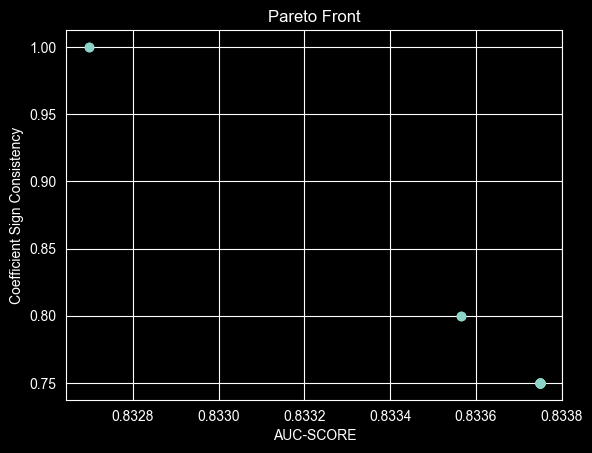

In [46]:
pareto: list[creator.Individual] = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

auc_values: list[float] = [ind.fitness.values[0] for ind in pareto]
sign_values: list[float] = [ind.fitness.values[1] for ind in pareto]

plt.scatter(auc_values, sign_values)
plt.xlabel("AUC-SCORE")
plt.ylabel("Coefficient Sign Consistency")
plt.title("Pareto Front")
plt.show()

In [47]:
# Convert Pareto front fitness values to numpy array
points: numpy.ndarray = numpy.array([ind.fitness.values for ind in pareto])

# Extreme points
max_auc_index: int = int(numpy.argmax(points[:, 0]))
max_sign_index: int = int(numpy.argmax(points[:, 1]))

max_auc_ind: creator.Individual = pareto[max_auc_index]
max_sign_ind: creator.Individual = pareto[max_sign_index]

# Knee-point calculation
p1: numpy.ndarray = points[max_auc_index]
p2: numpy.ndarray = points[max_sign_index]

if numpy.allclose(p1, p2):
    knee_index: int = 0
else:
    line_vector: numpy.ndarray = p2 - p1
    line_vector = line_vector / numpy.linalg.norm(line_vector)

    distances: list[float] = []

    for p in points:
        vector: numpy.ndarray = p - p1
        projection: numpy.ndarray = numpy.dot(vector, line_vector) * line_vector
        orthogonal: numpy.ndarray = vector - projection
        distances.append(float(numpy.linalg.norm(orthogonal)))

    knee_index: int = int(numpy.argmax(distances))

knee_ind: creator.Individual = pareto[knee_index]

# Helper function to extract info
def extract_info(individual) -> tuple[float, float, int, numpy.ndarray]:
    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    auc: float = individual.fitness.values[0]
    sign_consistency: float = individual.fitness.values[1]
    n_features: int = len(cols)
    return auc, sign_consistency, n_features, cols

auc1, sign1, nf1, cols1 = extract_info(max_auc_ind)
auc2, sign2, nf2, cols2 = extract_info(max_sign_ind)
auc3, sign3, nf3, cols3 = extract_info(knee_ind)

print("\n=== Pareto Front Model Comparison On Validation Set ===\n")

print("1) Maximum AUC model")
print(f"AUC on validation set: {auc1:.4f}")
print(f"Sign consistency on validation set: {sign1:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"AUC on validation set: {auc2:.4f}")
print(f"Sign consistency on validation set: {sign2:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"AUC on validation set: {auc3:.4f}")
print(f"Sign consistency on validation set: {sign3:.4f}")
print(f"Number of features: {nf3}")


=== Pareto Front Model Comparison On Validation Set ===

1) Maximum AUC model
AUC on validation set: 0.8337
Sign consistency on validation set: 0.7500
Number of features: 4

2) Maximum Sign Consistency model
AUC on validation set: 0.8327
Sign consistency on validation set: 1.0000
Number of features: 4

3) Knee-point model (balanced solution)
AUC on validation set: 0.8336
Sign consistency on validation set: 0.8000
Number of features: 5


In [48]:
# Calculate the final results on the test set
def evaluate_on_test(cols: numpy.ndarray) -> tuple[float, float]:
    X_search_reduced: numpy.ndarray = X_search[:, cols]
    X_test_reduced: numpy.ndarray = X_test.to_numpy()[:, cols]

    scaler: StandardScaler = StandardScaler()
    X_search_reduced_scaled: numpy.ndarray = scaler.fit_transform(X_search_reduced)
    X_test_reduced_scaled: numpy.ndarray = scaler.transform(X_test_reduced)

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED)
    model.fit(X_search_reduced_scaled, y_search)

    test_probs: numpy.ndarray = model.predict_proba(X_test_reduced_scaled)[:, 1]
    roc_auc: float = roc_auc_score(y_test, test_probs)
    pr_auc: float = average_precision_score(y_test, test_probs)

    return roc_auc, pr_auc

roc_auc1_t, pr_auc1_t = evaluate_on_test(cols1)
roc_auc2_t, pr_auc2_t = evaluate_on_test(cols2)
roc_auc3_t, pr_auc3_t = evaluate_on_test(cols3)

print("\n=== Test Set Model Comparison ===\n")

print("1) Maximum AUC model")
print(f"ROC-AUC on test set: {roc_auc1_t:.4f}")
print(f"PR-AUC on test set: {pr_auc1_t:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"ROC-AUC on test set: {roc_auc2_t:.4f}")
print(f"PR-AUC on test set: {pr_auc2_t:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"ROC-AUC on test set: {roc_auc3_t:.4f}")
print(f"PR-AUC on test set: {pr_auc3_t:.4f}")
print(f"Number of features: {nf3}")


=== Test Set Model Comparison ===

1) Maximum AUC model
ROC-AUC on test set: 0.8254
PR-AUC on test set: 0.6908
Number of features: 4

2) Maximum Sign Consistency model
ROC-AUC on test set: 0.8294
PR-AUC on test set: 0.6944
Number of features: 4

3) Knee-point model (balanced solution)
ROC-AUC on test set: 0.8267
PR-AUC on test set: 0.6901
Number of features: 5


# SINGLE OBJECTIVE

In [49]:
# Reset random seeds for reproducibility
random.seed(SEED)
numpy.random.seed(SEED)

In [50]:
# Cache the results of evaluate_multi
def evaluate_single(individual: Sequence[int]) -> tuple[float]:
    return _evaluate_single_cached(tuple(individual))

@lru_cache(maxsize=None)
def _evaluate_single_cached(individual: Sequence[int]) -> tuple[float]:
    if sum(individual) == 0:
        return (0.0,)

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    X_subset: numpy.ndarray = X_search[:, cols]

    auc_scores: list[float] = []

    for train_idx, val_idx in cv.split(X_subset, y_search):
        X_fold_train, X_fold_val = X_subset[train_idx], X_subset[val_idx]
        y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

        scaler: StandardScaler = StandardScaler()
        X_fold_train_scaled: numpy.ndarray = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled: numpy.ndarray = scaler.transform(X_fold_val)

        model: LogisticRegression = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED)
        model.fit(X_fold_train_scaled, y_fold_train)

        probs: numpy.ndarray = model.predict_proba(X_fold_val_scaled)[:, 1]

        if USE_ROC_AUC:
            fold_auc = roc_auc_score(y_fold_val, probs)
        else:
            fold_auc = average_precision_score(y_fold_val, probs)
        auc_scores.append(fold_auc)

    return (numpy.mean(auc_scores),)

In [51]:
if "FitnessSingle" not in creator.__dict__:
    creator.create("FitnessSingle", base.Fitness, weights=(1.0,))

if "IndividualSingle" not in creator.__dict__:
    creator.create("IndividualSingle", list, fitness=creator.FitnessSingle)

In [52]:
toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.IndividualSingle,
    toolbox.attr_bool,
    n=X_search.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_single)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(feature_names))
toolbox.register("select", tools.selTournament, tournsize=3)

pop: list[creator.IndividualSingle] = toolbox.population(n=POP_SIZE)
hof: tools.HallOfFame = tools.HallOfFame(1)

stats: tools.Statistics = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=NGEN,
    stats=stats,
    halloffame=hof,
    verbose=True
)

best_individual: creator.IndividualSingle = hof[0]
best_cols: list[int] = [i for i, bit in enumerate(best_individual) if bit == 1]

selected_feature_names: list[str] = [feature_names[i] for i in best_cols]
selected_feature_names.sort()
print("Selected features:", selected_feature_names)

gen	nevals	max     
0  	200   	0.832784
1  	121   	0.833749
2  	114   	0.833749
3  	123   	0.833749
4  	126   	0.833749
5  	126   	0.833749
6  	121   	0.833749
7  	123   	0.833749
8  	115   	0.833749
9  	121   	0.833749
10 	122   	0.833749
11 	115   	0.833749
12 	121   	0.833749
13 	117   	0.833749
14 	136   	0.833749
15 	122   	0.833749
16 	121   	0.833749
17 	115   	0.833749
18 	112   	0.833749
19 	134   	0.833749
20 	122   	0.833749
21 	131   	0.833749
22 	129   	0.833749
23 	128   	0.833749
24 	126   	0.833749
25 	126   	0.833749
26 	125   	0.833749
27 	128   	0.833749
28 	132   	0.833749
29 	116   	0.833749
30 	115   	0.833749
31 	126   	0.833749
32 	111   	0.833749
33 	120   	0.833749
34 	110   	0.833749
35 	131   	0.833749
36 	122   	0.833749
37 	121   	0.833749
38 	125   	0.833749
39 	130   	0.833749
40 	128   	0.833749
41 	112   	0.833749
42 	120   	0.833749
43 	134   	0.833749
44 	137   	0.833749
45 	112   	0.833749
46 	111   	0.833749
47 	123   	0.833749
48 	139   	0.833749


In [53]:
# Calculate the final results on the test set
X_search_reduced: numpy.ndarray = X_search[:, best_cols]
X_test_reduced: numpy.ndarray = X_test.to_numpy()[:, best_cols]

scaler: StandardScaler = StandardScaler()
X_search_reduced_scaled: numpy.ndarray = scaler.fit_transform(X_search_reduced)
X_test_reduced_scaled: numpy.ndarray = scaler.transform(X_test_reduced)

model: LogisticRegression = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED)
model.fit(X_search_reduced_scaled, y_search)

test_probs: numpy.ndarray = model.predict_proba(X_test_reduced_scaled)[:, 1]
test_roc_auc: float = roc_auc_score(y_test, test_probs)
test_pr_auc: float = average_precision_score(y_test, test_probs)

print("\n=== Test Set Model Comparison ===\n")

print(f"ROC-AUC on test set: {test_roc_auc:.4f}")
print(f"PR-AUC on test set: {test_pr_auc:.4f}")
print(f"Number of features: {len(best_cols)}")


=== Test Set Model Comparison ===

ROC-AUC on test set: 0.8254
PR-AUC on test set: 0.6908
Number of features: 4
